<a href="https://colab.research.google.com/github/Longhanhmid24/DoAn_Email/blob/main/Qwen_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
base_path = "/content/drive/MyDrive/Deep_Learning_Email/dataset_split/"
train_df = pd.read_csv(base_path + "train.csv")
val_df   = pd.read_csv(base_path + "val.csv")
test_df  = pd.read_csv(base_path + "test.csv")

Mounted at /content/drive


In [ ]:
pip install -q -U transformers datasets evaluate accelerate bitsandbytes peft trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 131.2 MB/s eta 0:00:00


In [ ]:
!pip uninstall -y pyarrow
!pip install pyarrow

Found existing installation: pyarrow 23.0.1
Uninstalling pyarrow-23.0.1:
  Successfully uninstalled pyarrow-23.0.1
  Using cached pyarrow-23.0.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.1 kB)
Using cached pyarrow-23.0.1-cp312-cp312-manylinux_2_28_x86_64.whl (47.6 MB)


In [ ]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer
from tqdm import tqdm

#### HUẤN LUYỆN QWEN (QLoRA FINE-TUNING)

In [ ]:
model_id = "Qwen/Qwen2.5-1.5B-Instruct"

# Cấu hình lượng tử hóa 4-bit để tiết kiệm bộ nhớ (QLoRA)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token # Qwen cần set pad_token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Load Model
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
model = prepare_model_for_kbit_training(model)

# Cấu hình LoRA
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, peft_config)

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
# The format_chatml function has been moved to cell vPXR9ZJ14wys to ensure it's defined before use.

In [ ]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)
train_dataset = train_dataset.map(format_chatml)
val_dataset = val_dataset.map(format_chatml)

Map:   0%|          | 0/5116 [00:00<?, ? examples/s]

Map:   0%|          | 0/639 [00:00<?, ? examples/s]

In [ ]:
from trl import SFTConfig

# Cấu hình Trainer
training_args = SFTConfig(
    output_dir="./qwen_finetuned",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,   # giảm mạnh
    max_grad_norm=1.0,    # chống nổ
    logging_steps=10,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    bf16=True,
    optim="paged_adamw_8bit",
    dataset_text_field="text",
     gradient_checkpointing=False,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    args=training_args,
)

print("Bắt đầu huấn luyện Qwen...")
trainer.train()

print("Đang lưu model...")

# 1. Lưu model + tokenizer
save_path = "/content/qwen_finetuned_final"

trainer.model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

# 2. Nén lại (để tải nhanh hơn)
import shutil
shutil.make_archive(save_path, 'zip', save_path)

# 3. Download về máy
from google.colab import files
files.download(save_path + ".zip")

print(" Đã lưu và tải model về máy!")

Adding EOS to train dataset:   0%|          | 0/5116 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/5116 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/639 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/639 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


...

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Đang lưu model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Đã lưu và tải model về máy!


#### ĐÁNH GIÁ VÀ VẼ BIỂU ĐỒ

In [ ]:
!pip install -q rouge_score sacrebleu bert_score

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_path = "/content/drive/MyDrive/Deep_Learning_Email/qwen_finetuned_final"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(model_path).to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

In [ ]:
import importlib
import evaluate
importlib.reload(evaluate)

import pandas as pd
import numpy as np
import math
import torch
from tqdm import tqdm
from datasets import Dataset

base_path = "/content/drive/MyDrive/Deep_Learning_Email/dataset_split/"
test_df = pd.read_csv(base_path + "test.csv")
test_dataset = Dataset.from_pandas(test_df)

print("Loaded test dataset:", len(test_dataset))

Loaded test dataset: 640


In [ ]:
def generate_responses(test_data, batch_size=16):
    model.eval()
    predictions = []
    references = []

    for i in tqdm(range(0, len(test_data), batch_size), desc="Generating"):
        batch = test_data[i:i+batch_size]

        batch = [dict(zip(batch.keys(), values)) for values in zip(*batch.values())]

        prompts = [
            f"<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n"
            f"<|im_start|>user\n{ex['Input_Text']}<|im_end|>\n"
            f"<|im_start|>assistant\n"
            for ex in batch
        ]

        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to("cuda")

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=128,
                temperature=0.7,
                top_p=0.9,
                pad_token_id=tokenizer.eos_token_id
            )

        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)

        for j, text in enumerate(decoded):
            gen = text[len(prompts[j]):].strip()
            predictions.append(gen)
            references.append(batch[j]['Output_Text'].strip())

    return predictions, references
predictions, references = generate_responses(test_dataset, batch_size=16)

import pickle
with open("/content/preds.pkl", "wb") as f:
    pickle.dump((predictions, references), f)

print(" Generate xong")

Generating: 100%|██████████| 40/40 [03:38<00:00,  5.47s/it]

 Generate xong


In [ ]:
import pickle
import numpy as np
import evaluate

# Load data
with open("/content/preds.pkl", "rb") as f:
    predictions, references = pickle.load(f)

# Clean dữ liệu (loại empty + strip)
clean_preds = []
clean_refs = []

for p, r in zip(predictions, references):
    if isinstance(p, str) and isinstance(r, str):
        p = p.strip()
        r = r.strip()
        if p != "" and r != "":
            clean_preds.append(p)
            clean_refs.append(r)

print("Total:", len(predictions))
print("Used:", len(clean_preds))
print("Removed empty:", len(predictions) - len(clean_preds))

# Load metrics
rouge = evaluate.load("rouge")
bleu = evaluate.load("sacrebleu")


rouge_results = rouge.compute(
    predictions=clean_preds,
    references=clean_refs
)

# BLEU (format CHUẨN sacrebleu)
bleu_results = bleu.compute(
    predictions=clean_preds,
    references=[[r] for r in clean_refs]  # đúng format
)

print("\nROUGE + BLEU")

# ROUGE đã là 0→1 rồi → KHÔNG nhân 100
print("ROUGE-1:", round(rouge_results["rouge1"], 4))
print("ROUGE-2:", round(rouge_results["rouge2"], 4))
print("ROUGE-L:", round(rouge_results["rougeL"], 4))

# BLEU sacrebleu là
bleu_score = bleu_results["score"]

print("BLEU Score:", round(bleu_score, 4))

Total: 640
Used: 89
Removed empty: 551

ROUGE + BLEU
ROUGE-1: 0.1487
ROUGE-2: 0.0091
ROUGE-L: 0.0938
BLEU Score: 0.2502


In [ ]:
 import pickle
import numpy as np
import evaluate
import warnings
import logging

# Tắt warning (optional)
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

# Load data
with open("/content/preds.pkl", "rb") as f:
    predictions, references = pickle.load(f)

# Clean dữ liệu (loại empty)
clean_preds = []
clean_refs = []

for p, r in zip(predictions, references):
    if isinstance(p, str) and isinstance(r, str):
        if p.strip() != "" and r.strip() != "":
            clean_preds.append(p.strip())
            clean_refs.append(r.strip())

print("Total:", len(predictions))
print("Used:", len(clean_preds))
print("Removed empty:", len(predictions) - len(clean_preds))

# Load metric
bertscore = evaluate.load("bertscore")

# Compute
results = bertscore.compute(
    predictions=clean_preds,
    references=clean_refs,
    lang="en",
    batch_size=16,
    model_type="bert-base-uncased"
)

# Output
f1 = np.mean(results["f1"])
prec = np.mean(results["precision"])
rec = np.mean(results["recall"])

print("\nBERTScore")
print("BERTScore F1:", round(f1, 4))
print("BERTScore Prec:", round(prec, 4))
print("BERTScore Rec:", round(rec, 4))

Total: 640
Used: 89
Removed empty: 551


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


BERTScore
BERTScore F1: 0.4433
BERTScore Prec: 0.468
BERTScore Rec: 0.4255


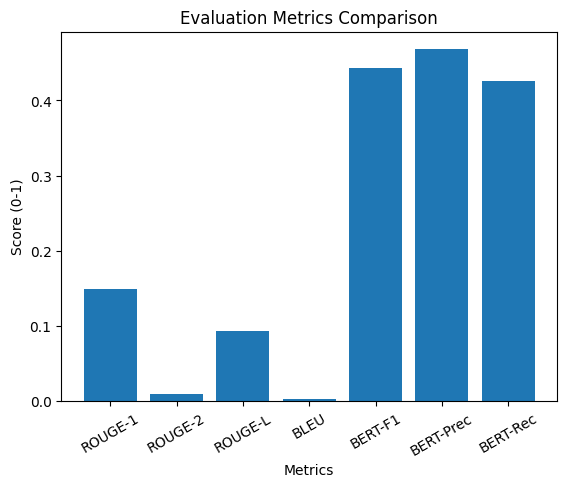

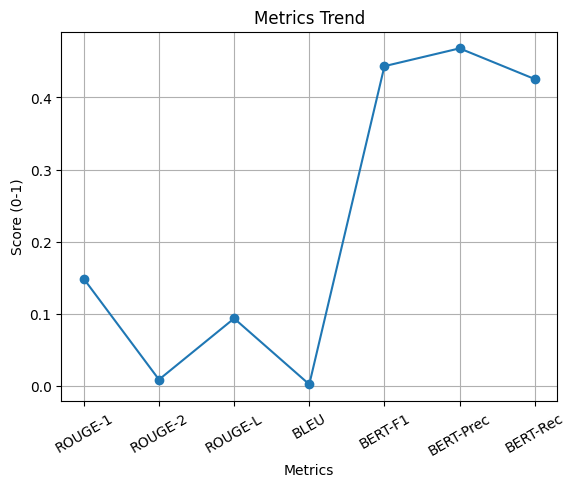

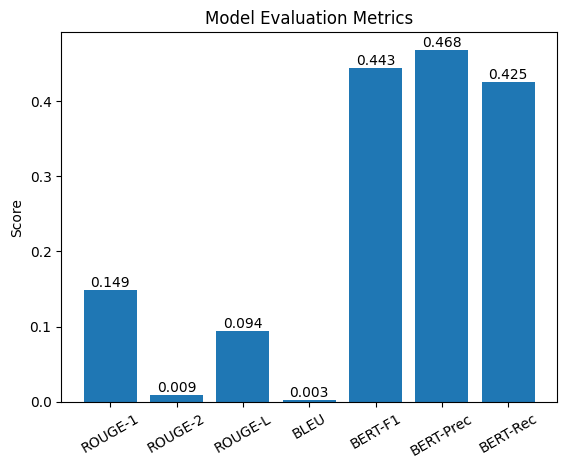

In [ ]:
import matplotlib.pyplot as plt


metrics = {
    "ROUGE-1": rouge_results["rouge1"],
    "ROUGE-2": rouge_results["rouge2"],
    "ROUGE-L": rouge_results["rougeL"],
    "BLEU": bleu_results["score"] / 100,   # đưa về 0–1
    "BERT-F1": f1,
    "BERT-Prec": prec,
    "BERT-Rec": rec
}

names = list(metrics.keys())
values = list(metrics.values())


plt.figure()
plt.bar(names, values)
plt.title("Evaluation Metrics Comparison")
plt.xlabel("Metrics")
plt.ylabel("Score (0-1)")
plt.xticks(rotation=30)
plt.show()


plt.figure()
plt.plot(names, values, marker='o')
plt.title("Metrics Trend")
plt.xlabel("Metrics")
plt.ylabel("Score (0-1)")
plt.grid()
plt.xticks(rotation=30)
plt.show()

plt.figure()

bars = plt.bar(names, values)

# Hiện số trên cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.3f}", ha='center', va='bottom')

plt.title("Model Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.show()

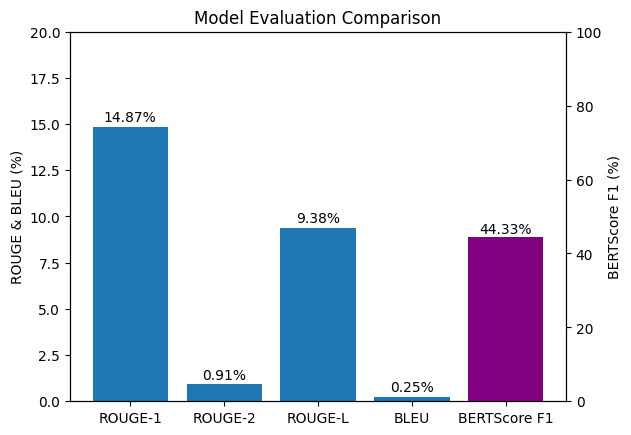

In [ ]:
import matplotlib.pyplot as plt

# ===== DATA =====
labels_left = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BLEU"]
labels_right = ["BERTScore F1"]

left_values = [
    rouge_results["rouge1"] * 100,
    rouge_results["rouge2"] * 100,
    rouge_results["rougeL"] * 100,
    bleu_results["score"]
]

right_value = f1 * 100

# ===== PLOT =====
fig, ax1 = plt.subplots()

# --- LEFT ---
bars1 = ax1.bar(labels_left, left_values)
ax1.set_ylabel("ROUGE & BLEU (%)")
ax1.set_ylim(0, 20)

#  thêm % trên cột trái
for bar in bars1:
    y = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.3,
        f"{y:.2f}%",
        ha='center'
    )

# --- RIGHT ---
ax2 = ax1.twinx()
bars2 = ax2.bar(labels_right, [right_value], color="purple")
ax2.set_ylabel("BERTScore F1 (%)")
ax2.set_ylim(0, 100)


for bar in bars2:
    y = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        y + 1,
        f"{y:.2f}%",
        ha='center'
    )

# ===== TITLE =====
plt.title("Model Evaluation Comparison")

plt.show()